In [3]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("data/DATA.CSV")

In [8]:
data = np.genfromtxt("data/DATA.CSV")   # auto-detects whitespace/tabs, ignores trailing blanks

print(data)
print(data.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


In [9]:
# equipment constants
GAIN_uV_per_unit = 1024      # A/D converter gain
SAMPLING_FREQ_HZ = 1000      # samples per second

# convert raw values to millivolts
ecg_mV = data * GAIN_uV_per_unit / 1000   # µV -> mV

# build the time axis (in seconds)
n_samples = data.shape[0]
time_s = np.arange(n_samples) / SAMPLING_FREQ_HZ

print(ecg_mV.shape)
print(time_s[:5], "...", time_s[-5:])

(6500, 3)
[0.    0.001 0.002 0.003 0.004] ... [6.495 6.496 6.497 6.498 6.499]


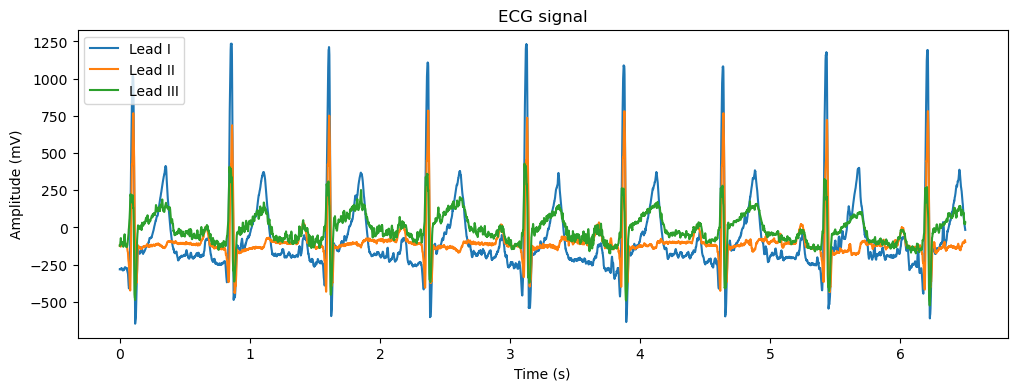

In [10]:
# plot the ECG data (all 3 leads on one plot)
plt.figure(figsize=(12, 4))
plt.plot(time_s, ecg_mV)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("ECG signal")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.show()

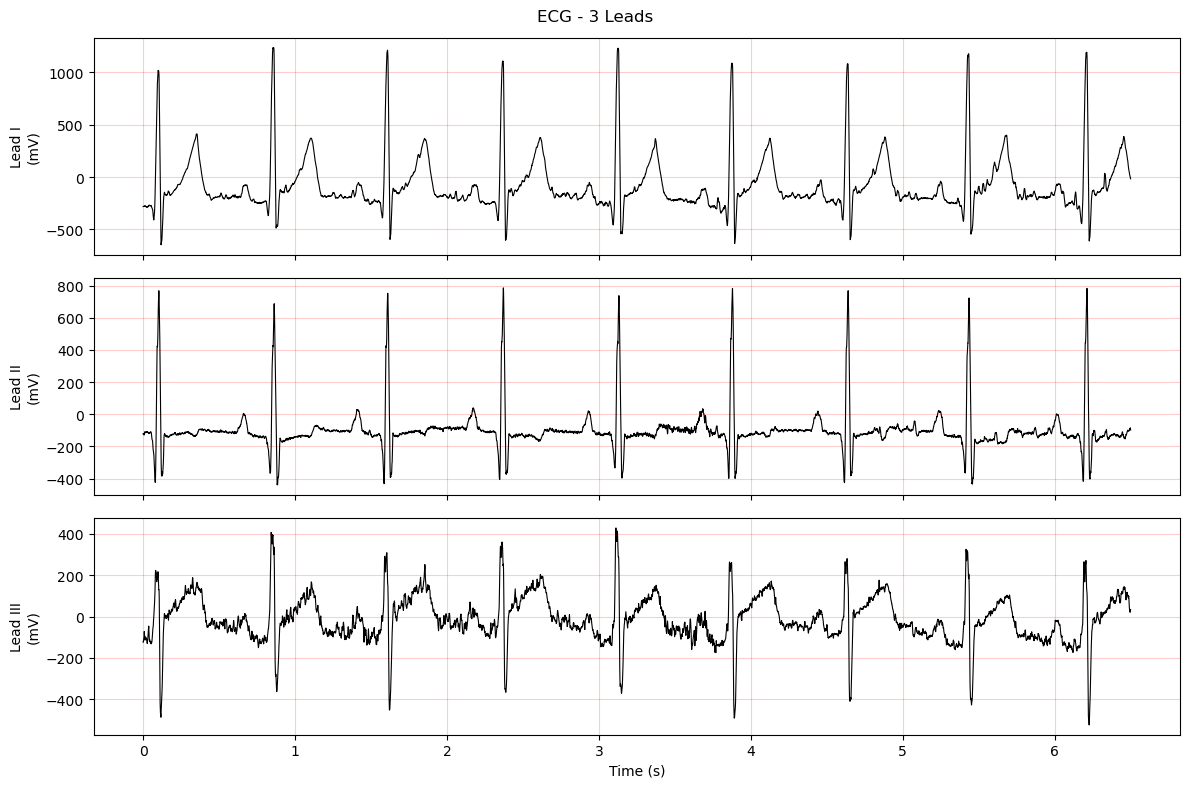

In [11]:
# realistic ECG-style plot with one subplot per lead
lead_names = ["I", "II", "III"]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(time_s, ecg_mV[:, i], color="black", linewidth=0.8)
    ax.set_ylabel(f"Lead {lead_names[i]}\n(mV)")
    ax.grid(True, which="both", color="red", alpha=0.2)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("ECG - 3 Leads")
plt.tight_layout()
plt.show()